# Labwork 5: Gaussian Blur (7x7)

In [1]:
import math
import time

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import cuda

In [3]:
inputImage = plt.imread("/content/images.jpg")

imageHeight, imageWidth = inputImage.shape[:2]

print("Image shape:", inputImage.shape)

Image shape: (750, 1200, 3)


## 1. Gaussian filter 7x7

In [4]:
gaussianFilter = np.array([
    [0,  0,   1,   2,   1,  0, 0],
    [0,  3,  13,  22,  13,  3, 0],
    [1, 13,  59,  97,  59, 13, 1],
    [2, 22,  97, 159,  97, 22, 2],
    [1, 13,  59,  97,  59, 13, 1],
    [0,  3,  13,  22,  13,  3, 0],
    [0,  0,   1,   2,   1,  0, 0],
], dtype=np.int32)

print("Filter sum:", gaussianFilter.sum())

Filter sum: 1003


## 2. CPU

In [5]:
cpuOutput = np.zeros_like(inputImage)

start = time.time()
for y in range(imageHeight):
    for x in range(imageWidth):
        for c in range(3):
            total = 0
            weightSum = 0
            for i in range(7):
                for j in range(7):
                    ny = y + i - 3
                    nx = x + j - 3
                    if ny >= 0 and ny < imageHeight and nx >= 0 and nx < imageWidth:
                        total += gaussianFilter[i, j] * int(inputImage[ny, nx, c])
                        weightSum += gaussianFilter[i, j]
            cpuOutput[y, x, c] = np.uint8(total / weightSum)
cpuTime = time.time() - start

print("CPU time:", cpuTime)

CPU time: 192.66942143440247


## 3. GPU without shared memory

In [6]:
@cuda.jit
def blur(src, dst, filt):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidy < src.shape[0] and tidx < src.shape[1]:
        for c in range(3):
            total = 0
            weightSum = 0
            for i in range(7):
                for j in range(7):
                    ny = tidy + i - 3
                    nx = tidx + j - 3
                    if ny >= 0 and ny < src.shape[0] and nx >= 0 and nx < src.shape[1]:
                        total += filt[i, j] * src[ny, nx, c]
                        weightSum += filt[i, j]
            dst[tidy, tidx, c] = np.uint8(total / weightSum)

## 4. GPU with shared memory

In [7]:
@cuda.jit
def blur_shared(src, dst, filt):
    # copy the filter to shared memory
    sFilter = cuda.shared.array((7, 7), numba.int32)
    if cuda.threadIdx.x < 7 and cuda.threadIdx.y < 7:
        sFilter[cuda.threadIdx.y, cuda.threadIdx.x] = filt[cuda.threadIdx.y, cuda.threadIdx.x]
    cuda.syncthreads()

    # same as before, but read the filter from shared memory
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidy < src.shape[0] and tidx < src.shape[1]:
        for c in range(3):
            total = 0
            weightSum = 0
            for i in range(7):
                for j in range(7):
                    ny = tidy + i - 3
                    nx = tidx + j - 3
                    if ny >= 0 and ny < src.shape[0] and nx >= 0 and nx < src.shape[1]:
                        total += sFilter[i, j] * src[ny, nx, c]
                        weightSum += sFilter[i, j]
            dst[tidy, tidx, c] = np.uint8(total / weightSum)

## 5. Run on GPU (16x16 blocks)

GPU time without shared: 0.0020949840545654297 | speedup: 91967.01092523045
GPU time with shared:    0.002032041549682617 | speedup: 94815.68989792326
Same result as CPU: True True


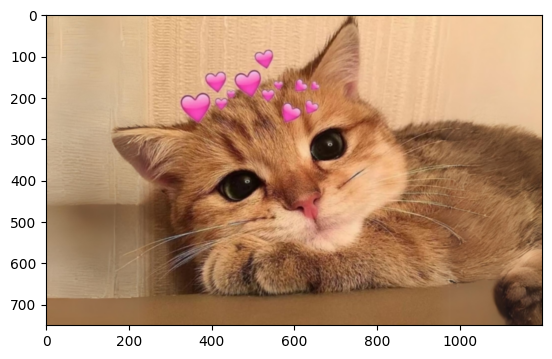

In [8]:
blockSize = (16, 16)
gridSize = (math.ceil(imageWidth / 16), math.ceil(imageHeight / 16))

devInput = cuda.to_device(inputImage)
devOutput = cuda.device_array((imageHeight, imageWidth, 3), np.uint8)
devFilter = cuda.to_device(gaussianFilter)

# first call compiles the kernels, so we do not time it
blur[gridSize, blockSize](devInput, devOutput, devFilter)
blur_shared[gridSize, blockSize](devInput, devOutput, devFilter)
cuda.synchronize()

# without shared memory
start = time.time()
blur[gridSize, blockSize](devInput, devOutput, devFilter)
cuda.synchronize()
gpuTime = time.time() - start
gpuOutput = devOutput.copy_to_host()

# with shared memory
start = time.time()
blur_shared[gridSize, blockSize](devInput, devOutput, devFilter)
cuda.synchronize()
gpuSharedTime = time.time() - start
gpuSharedOutput = devOutput.copy_to_host()

print("GPU time without shared:", gpuTime, "| speedup:", cpuTime / gpuTime)
print("GPU time with shared:   ", gpuSharedTime, "| speedup:", cpuTime / gpuSharedTime)
print("Same result as CPU:", np.array_equal(cpuOutput, gpuOutput), np.array_equal(cpuOutput, gpuSharedOutput))

plt.imsave("blur_gpu.png", gpuSharedOutput)
plt.imshow(gpuSharedOutput)
plt.show()

## 6. Block size vs speedup (with / without shared memory)

8 x 8 | without shared: 0.0019411849975585938 | with shared: 0.001827840805053711
12 x 12 | without shared: 0.001909022331237793 | with shared: 0.0009998464584350586
16 x 16 | without shared: 0.0009338808059692383 | with shared: 0.000964665412902832
24 x 24 | without shared: 0.0011580181121826172 | with shared: 0.0010255241394042968
32 x 32 | without shared: 0.0008960437774658204 | with shared: 0.0009155464172363281


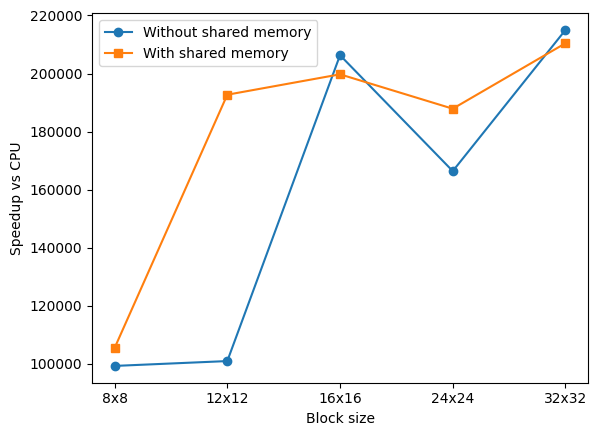

In [9]:
sizes = [8, 12, 16, 24, 32]
speedup = []
speedupShared = []

for s in sizes:
    blockSize = (s, s)
    gridSize = (math.ceil(imageWidth / s), math.ceil(imageHeight / s))

    start = time.time()
    for _ in range(50):
        blur[gridSize, blockSize](devInput, devOutput, devFilter)
    cuda.synchronize()
    t = (time.time() - start) / 50
    speedup.append(cpuTime / t)

    start = time.time()
    for _ in range(50):
        blur_shared[gridSize, blockSize](devInput, devOutput, devFilter)
    cuda.synchronize()
    tShared = (time.time() - start) / 50
    speedupShared.append(cpuTime / tShared)

    print(s, "x", s, "| without shared:", t, "| with shared:", tShared)

labels = [f"{s}x{s}" for s in sizes]
plt.plot(labels, speedup, marker="o", label="Without shared memory")
plt.plot(labels, speedupShared, marker="s", label="With shared memory")
plt.xlabel("Block size")
plt.ylabel("Speedup vs CPU")
plt.legend()
plt.savefig("blocksize_vs_speedup.png")
plt.show()